In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

Libraries imported successfully!


In [2]:
df = pd.read_csv('Customer Churn.csv')
df.columns = df.columns.str.strip()

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset shape: (3150, 14)

Columns: ['Call  Failure', 'Complains', 'Subscription  Length', 'Charge  Amount', 'Seconds of Use', 'Frequency of use', 'Frequency of SMS', 'Distinct Called Numbers', 'Age Group', 'Tariff Plan', 'Status', 'Age', 'Customer Value', 'Churn']


,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Call  Failure            3150 non-null   int64  
 1   Complains                3150 non-null   int64  
 2   Subscription  Length     3150 non-null   int64  
 3   Charge  Amount           3150 non-null   int64  
 4   Seconds of Use           3150 non-null   int64  
 5   Frequency of use         3150 non-null   int64  
 6   Frequency of SMS         3150 non-null   int64  
 7   Distinct Called Numbers  3150 non-null   int64  
 8   Age Group                3150 non-null   int64  
 9   Tariff Plan              3150 non-null   int64  
 10  Status                   3150 non-null   int64  
 11  Age                      3150 non-null   int64  
 12  Customer Value           3150 non-null   float64
 13  Churn                    3150 non-null   int64  
dtypes: float64(1), int64(13)

In [4]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values:
Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

Total missing: 0


In [5]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 300


Data Cleaning

In [6]:
# Remove duplicates
df_clean = df.drop_duplicates()
print(f"Original shape: {df.shape}")
print(f"After removing duplicates: {df_clean.shape}")
print(f"Duplicates removed: {df.shape[0] - df_clean.shape[0]}")

Original shape: (3150, 14)
After removing duplicates: (2850, 14)
Duplicates removed: 300


Summary Statistics

In [7]:
df_clean.describe()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000,2850.000000
mean,7.802456,0.080702,32.452982,0.974737,4534.243158,70.484912,73.789825,23.870526,2.835088,1.080351,1.240000,31.077193,474.990367,0.156491
std,7.326172,0.272424,8.723075,1.550618,4199.712303,57.401512,112.062397,17.193929,0.893503,0.271883,0.427158,8.861934,514.442198,0.363384
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,29.000000,0.000000,1458.750000,28.000000,7.000000,11.000000,2.000000,1.000000,1.000000,25.000000,117.527500,0.000000
50%,6.000000,0.000000,35.000000,0.000000,3041.000000,54.500000,22.000000,21.000000,3.000000,1.000000,1.000000,30.000000,232.520000,0.000000
75%,12.000000,0.000000,38.000000,2.000000,6500.000000,96.000000,88.000000,34.000000,3.000000,1.000000,1.000000,30.000000,790.080000,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


In [8]:
print("Churn Distribution:")
print(df_clean['Churn'].value_counts())
print(f"\nChurn Rate: {df_clean['Churn'].mean()*100:.2f}%")
print(f"Retention Rate: {(1-df_clean['Churn'].mean())*100:.2f}%")

Churn Distribution:
Churn
0    2404
1     446
Name: count, dtype: int64

Churn Rate: 15.65%
Retention Rate: 84.35%


In [9]:
for col in df_clean.select_dtypes(include=[np.number]).columns:
    print(f"\n{col}:")
    print(f"  Min: {df_clean[col].min()}")
    print(f"  Max: {df_clean[col].max()}")
    print(f"  Mean: {df_clean[col].mean():.2f}")
    print(f"  Median: {df_clean[col].median():.2f}")
    print(f"  Std: {df_clean[col].std():.2f}")


Call  Failure:
  Min: 0
  Max: 36
  Mean: 7.80
  Median: 6.00
  Std: 7.33

Complains:
  Min: 0
  Max: 1
  Mean: 0.08
  Median: 0.00
  Std: 0.27

Subscription  Length:
  Min: 3
  Max: 47
  Mean: 32.45
  Median: 35.00
  Std: 8.72

Charge  Amount:
  Min: 0
  Max: 10
  Mean: 0.97
  Median: 0.00
  Std: 1.55

Seconds of Use:
  Min: 0
  Max: 17090
  Mean: 4534.24
  Median: 3041.00
  Std: 4199.71

Frequency of use:
  Min: 0
  Max: 255
  Mean: 70.48
  Median: 54.50
  Std: 57.40

Frequency of SMS:
  Min: 0
  Max: 522
  Mean: 73.79
  Median: 22.00
  Std: 112.06

Distinct Called Numbers:
  Min: 0
  Max: 97
  Mean: 23.87
  Median: 21.00
  Std: 17.19

Age Group:
  Min: 1
  Max: 5
  Mean: 2.84
  Median: 3.00
  Std: 0.89

Tariff Plan:
  Min: 1
  Max: 2
  Mean: 1.08
  Median: 1.00
  Std: 0.27

Status:
  Min: 1
  Max: 2
  Mean: 1.24
  Median: 1.00
  Std: 0.43

Age:
  Min: 15
  Max: 55
  Mean: 31.08
  Median: 30.00
  Std: 8.86

Customer Value:
  Min: 0.0
  Max: 2165.28
  Mean: 474.99
  Median: 232.52
  

Correlation Analysis

In [10]:
correlation_matrix = df_clean.corr()

print("Correlation with Churn (sorted):")
print(correlation_matrix['Churn'].sort_values(ascending=False))

Correlation with Churn (sorted):
Churn                      1.000000
Complains                  0.546055
Status                     0.492867
Call  Failure              0.003310
Age Group                 -0.005891
Age                       -0.011491
Subscription  Length      -0.037984
Tariff Plan               -0.106000
Charge  Amount            -0.201662
Frequency of SMS          -0.218894
Distinct Called Numbers   -0.270343
Customer Value            -0.287078
Seconds of Use            -0.295999
Frequency of use          -0.298608
Name: Churn, dtype: float64


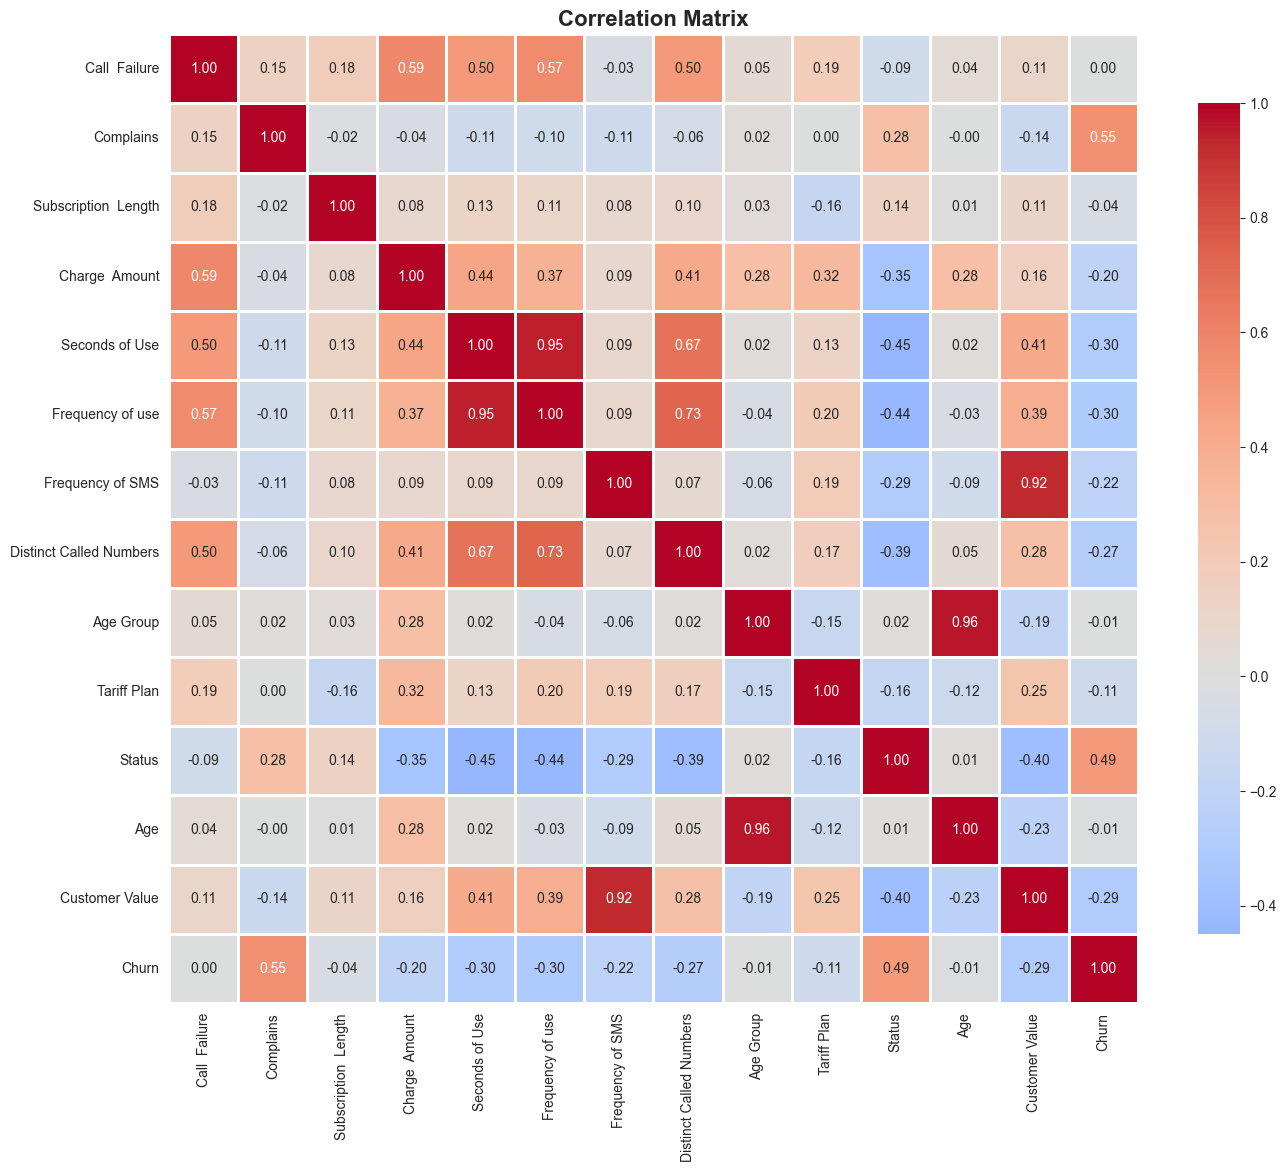

In [11]:
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Data Visualization

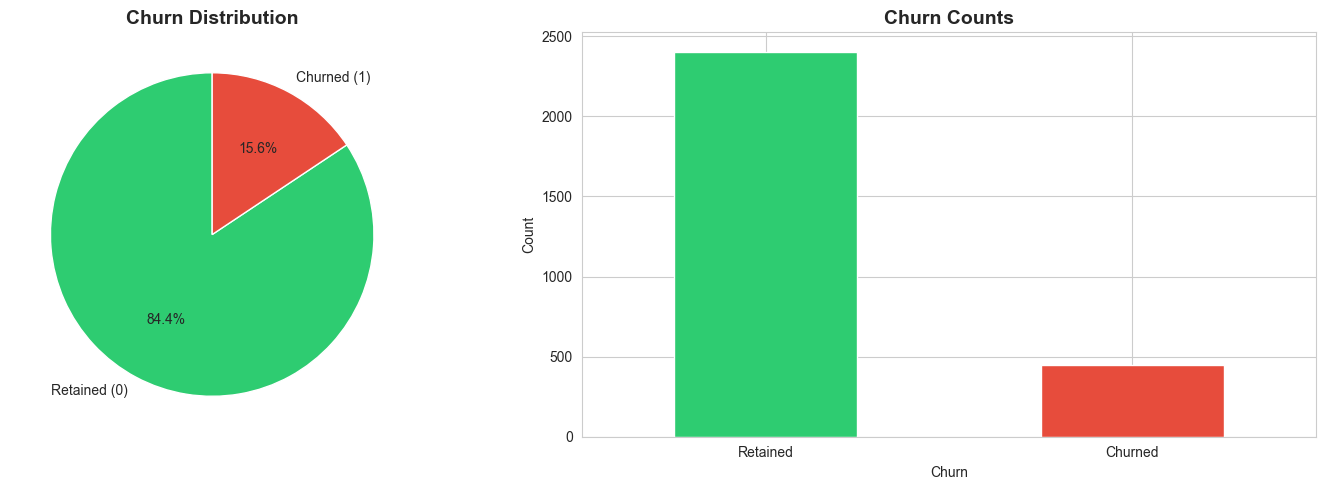

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

churn_counts = df_clean['Churn'].value_counts()
ax[0].pie(churn_counts, labels=['Retained (0)', 'Churned (1)'], autopct='%1.1f%%', 
          colors=['#2ecc71', '#e74c3c'], startangle=90)
ax[0].set_title('Churn Distribution', fontweight='bold', fontsize=14)

churn_counts.plot(kind='bar', ax=ax[1], color=['#2ecc71', '#e74c3c'])
ax[1].set_title('Churn Counts', fontweight='bold', fontsize=14)
ax[1].set_xlabel('Churn')
ax[1].set_ylabel('Count')
ax[1].set_xticklabels(['Retained', 'Churned'], rotation=0)

plt.tight_layout()
plt.show()

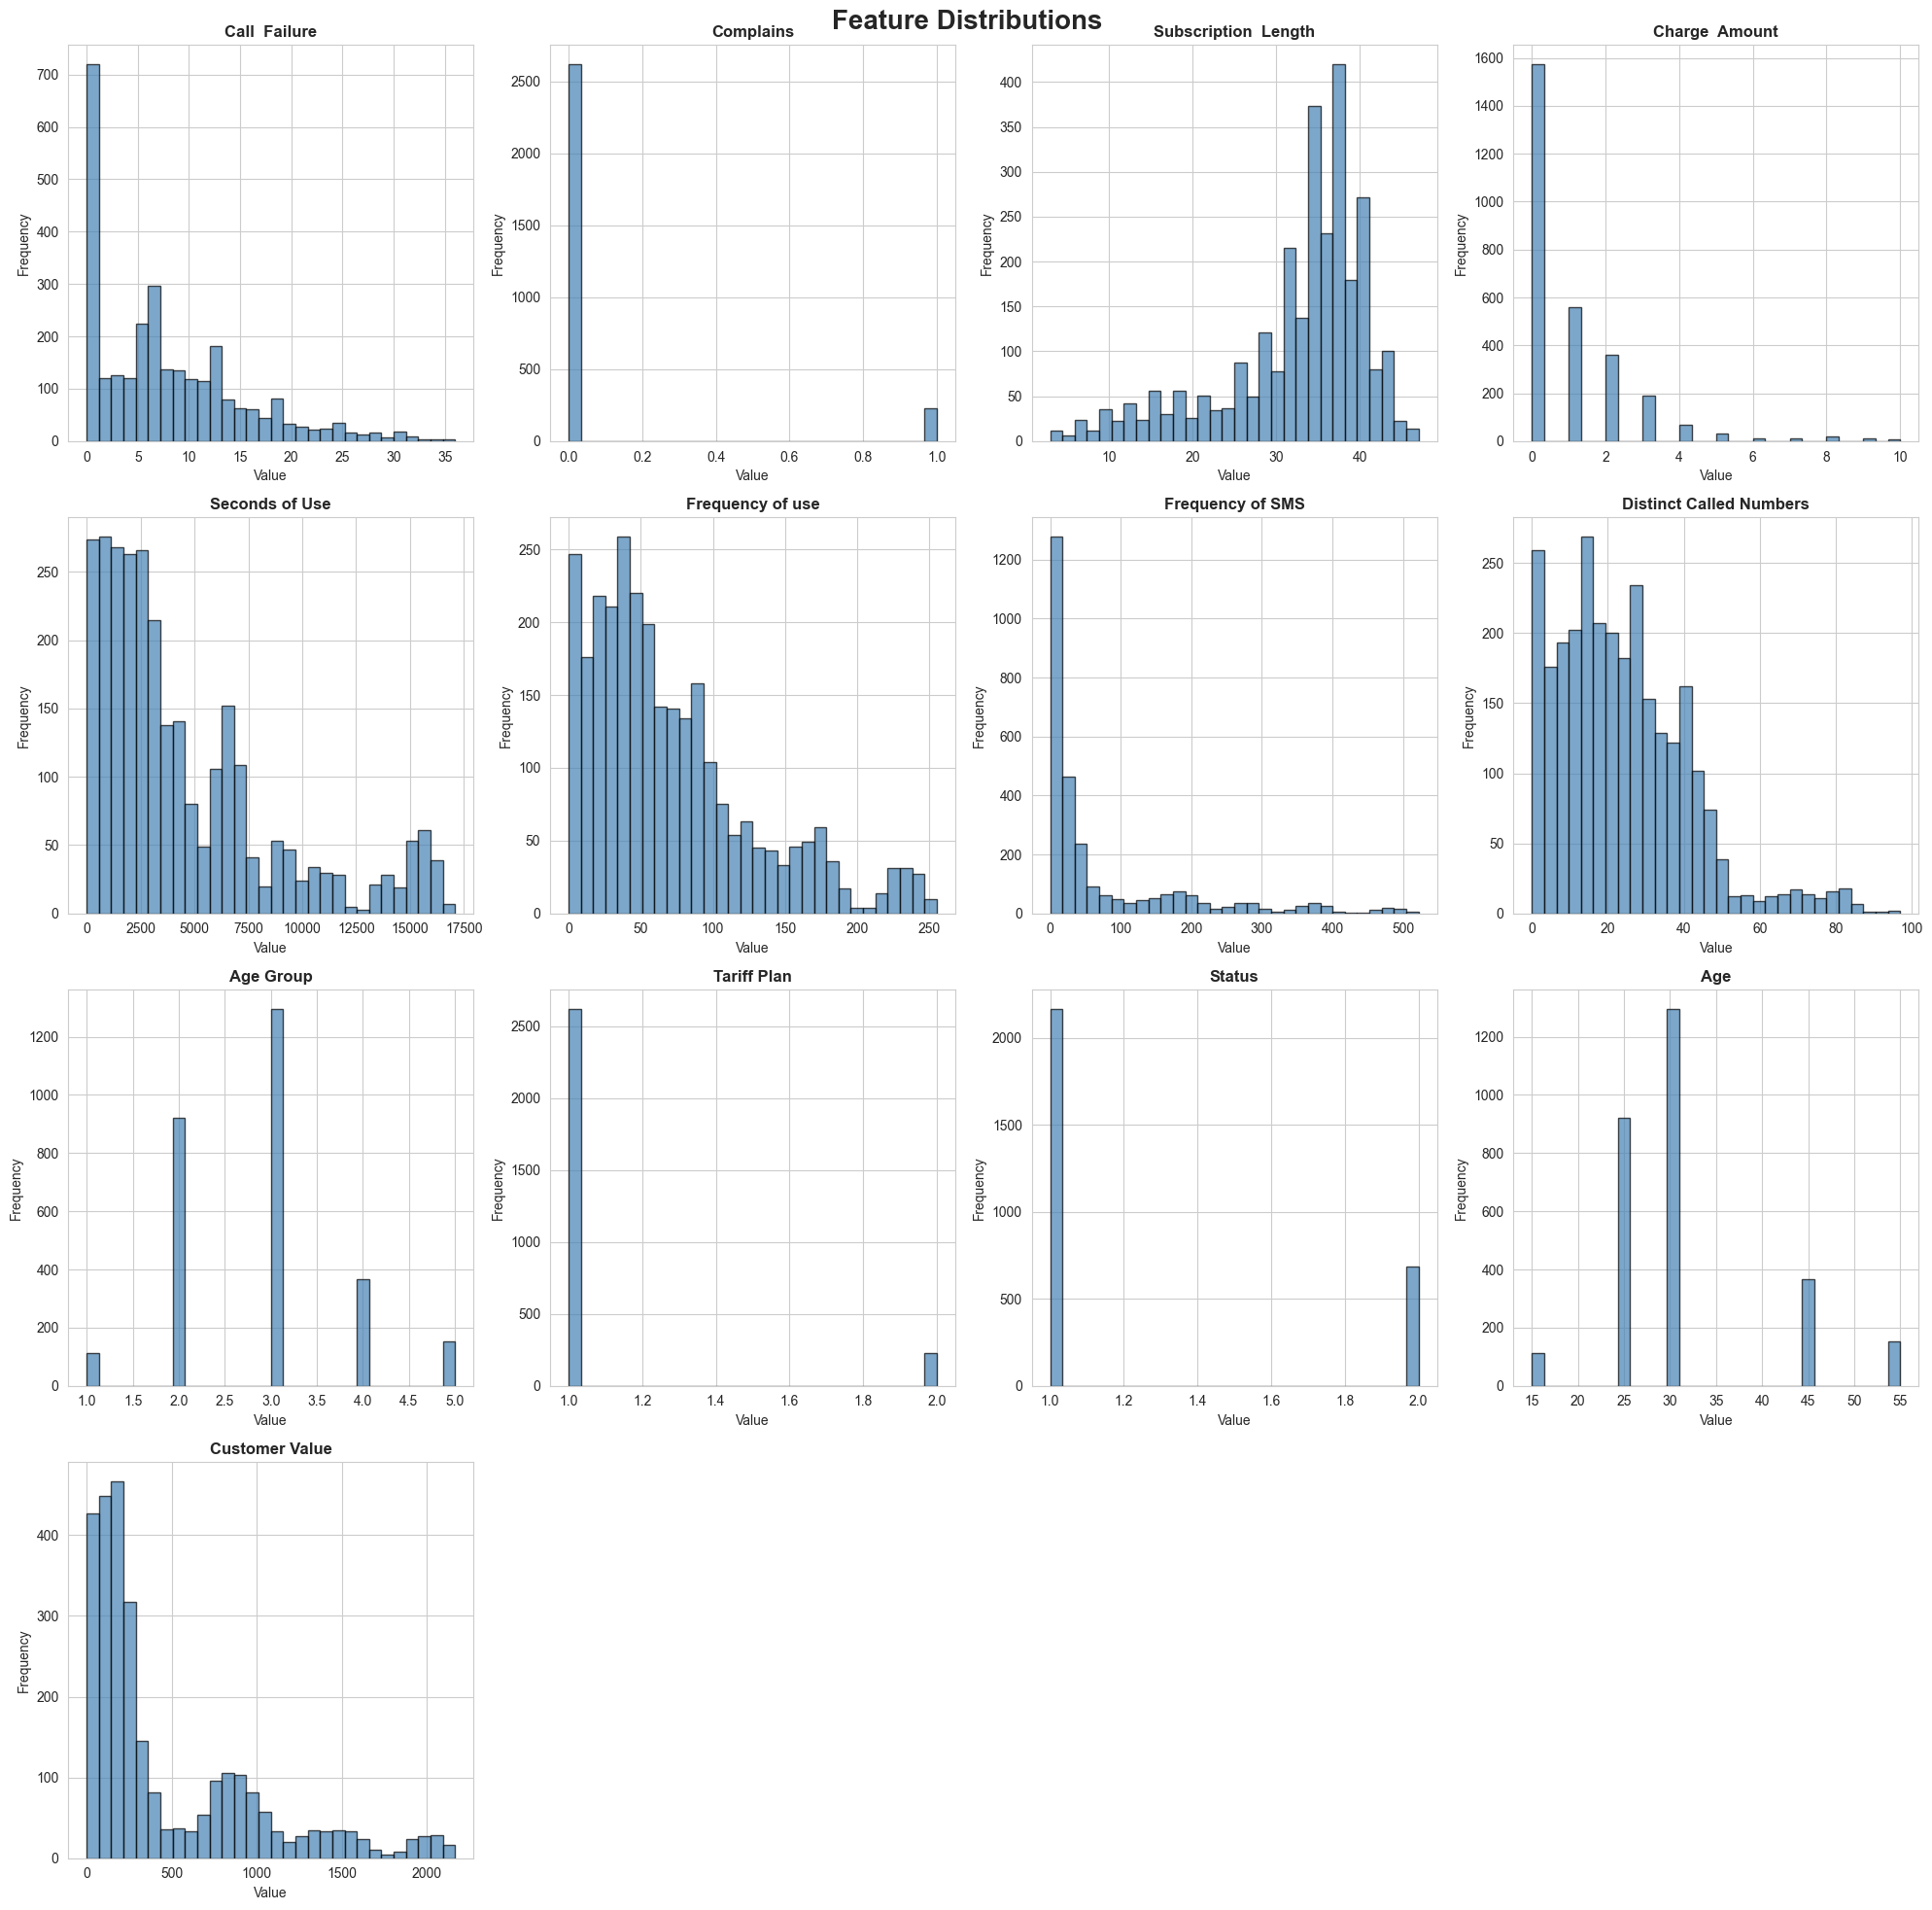

In [13]:
# Feature distributions
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols.remove('Churn')

n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df_clean[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(col, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')

# Hide unused subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Feature Distributions', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

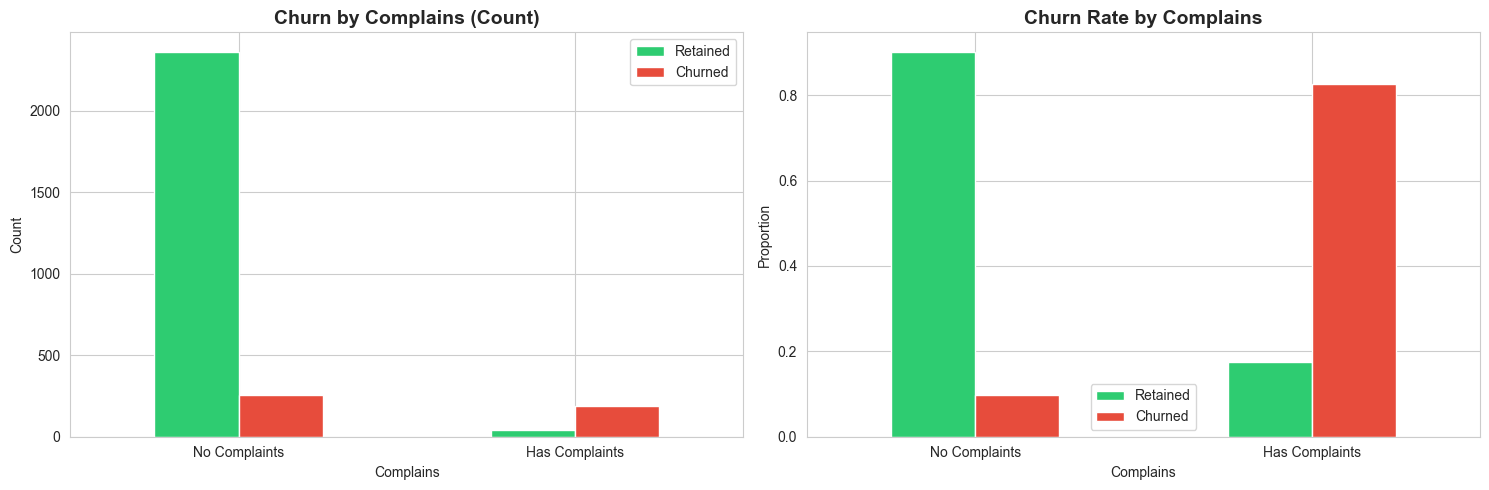

In [14]:
# Churn by Complains
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

pd.crosstab(df_clean['Complains'], df_clean['Churn']).plot(kind='bar', ax=ax[0], 
                                                             color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Churn by Complains (Count)', fontweight='bold', fontsize=14)
ax[0].set_xlabel('Complains')
ax[0].set_ylabel('Count')
ax[0].legend(['Retained', 'Churned'])
ax[0].set_xticklabels(['No Complaints', 'Has Complaints'], rotation=0)

pd.crosstab(df_clean['Complains'], df_clean['Churn'], normalize='index').plot(kind='bar', ax=ax[1],
                                                                                 color=['#2ecc71', '#e74c3c'])
ax[1].set_title('Churn Rate by Complains', fontweight='bold', fontsize=14)
ax[1].set_xlabel('Complains')
ax[1].set_ylabel('Proportion')
ax[1].legend(['Retained', 'Churned'])
ax[1].set_xticklabels(['No Complaints', 'Has Complaints'], rotation=0)

plt.tight_layout()
plt.show()

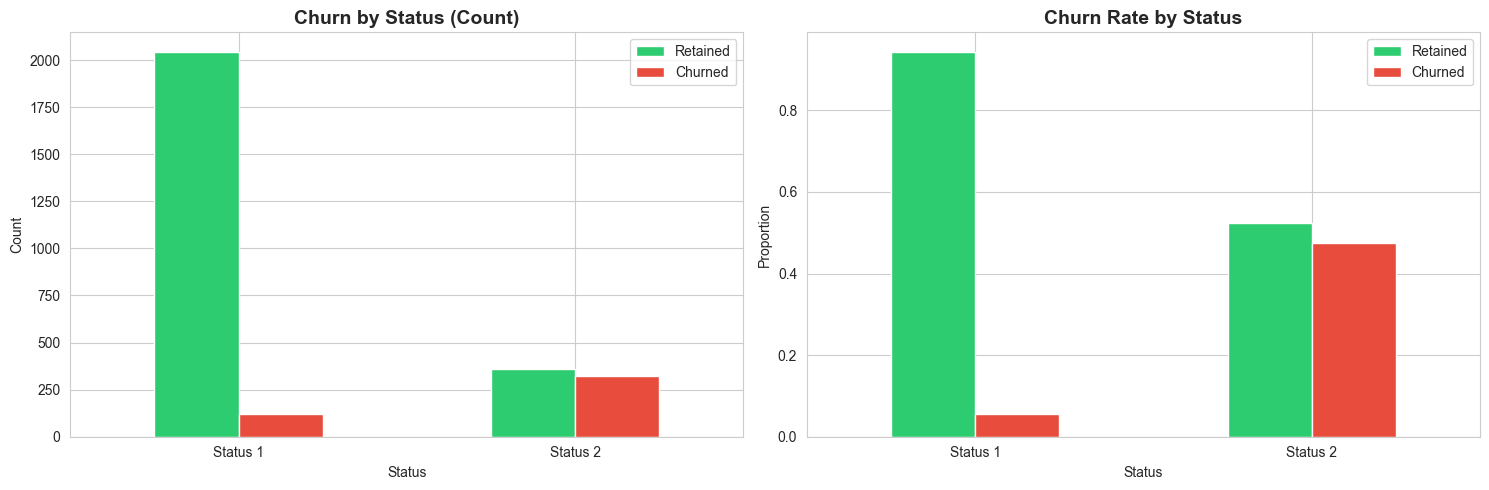

In [15]:
# Churn by Status
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

pd.crosstab(df_clean['Status'], df_clean['Churn']).plot(kind='bar', ax=ax[0],
                                                          color=['#2ecc71', '#e74c3c'])
ax[0].set_title('Churn by Status (Count)', fontweight='bold', fontsize=14)
ax[0].set_xlabel('Status')
ax[0].set_ylabel('Count')
ax[0].legend(['Retained', 'Churned'])
ax[0].set_xticklabels(['Status 1', 'Status 2'], rotation=0)

pd.crosstab(df_clean['Status'], df_clean['Churn'], normalize='index').plot(kind='bar', ax=ax[1],
                                                                             color=['#2ecc71', '#e74c3c'])
ax[1].set_title('Churn Rate by Status', fontweight='bold', fontsize=14)
ax[1].set_xlabel('Status')
ax[1].set_ylabel('Proportion')
ax[1].legend(['Retained', 'Churned'])
ax[1].set_xticklabels(['Status 1', 'Status 2'], rotation=0)

plt.tight_layout()
plt.show()

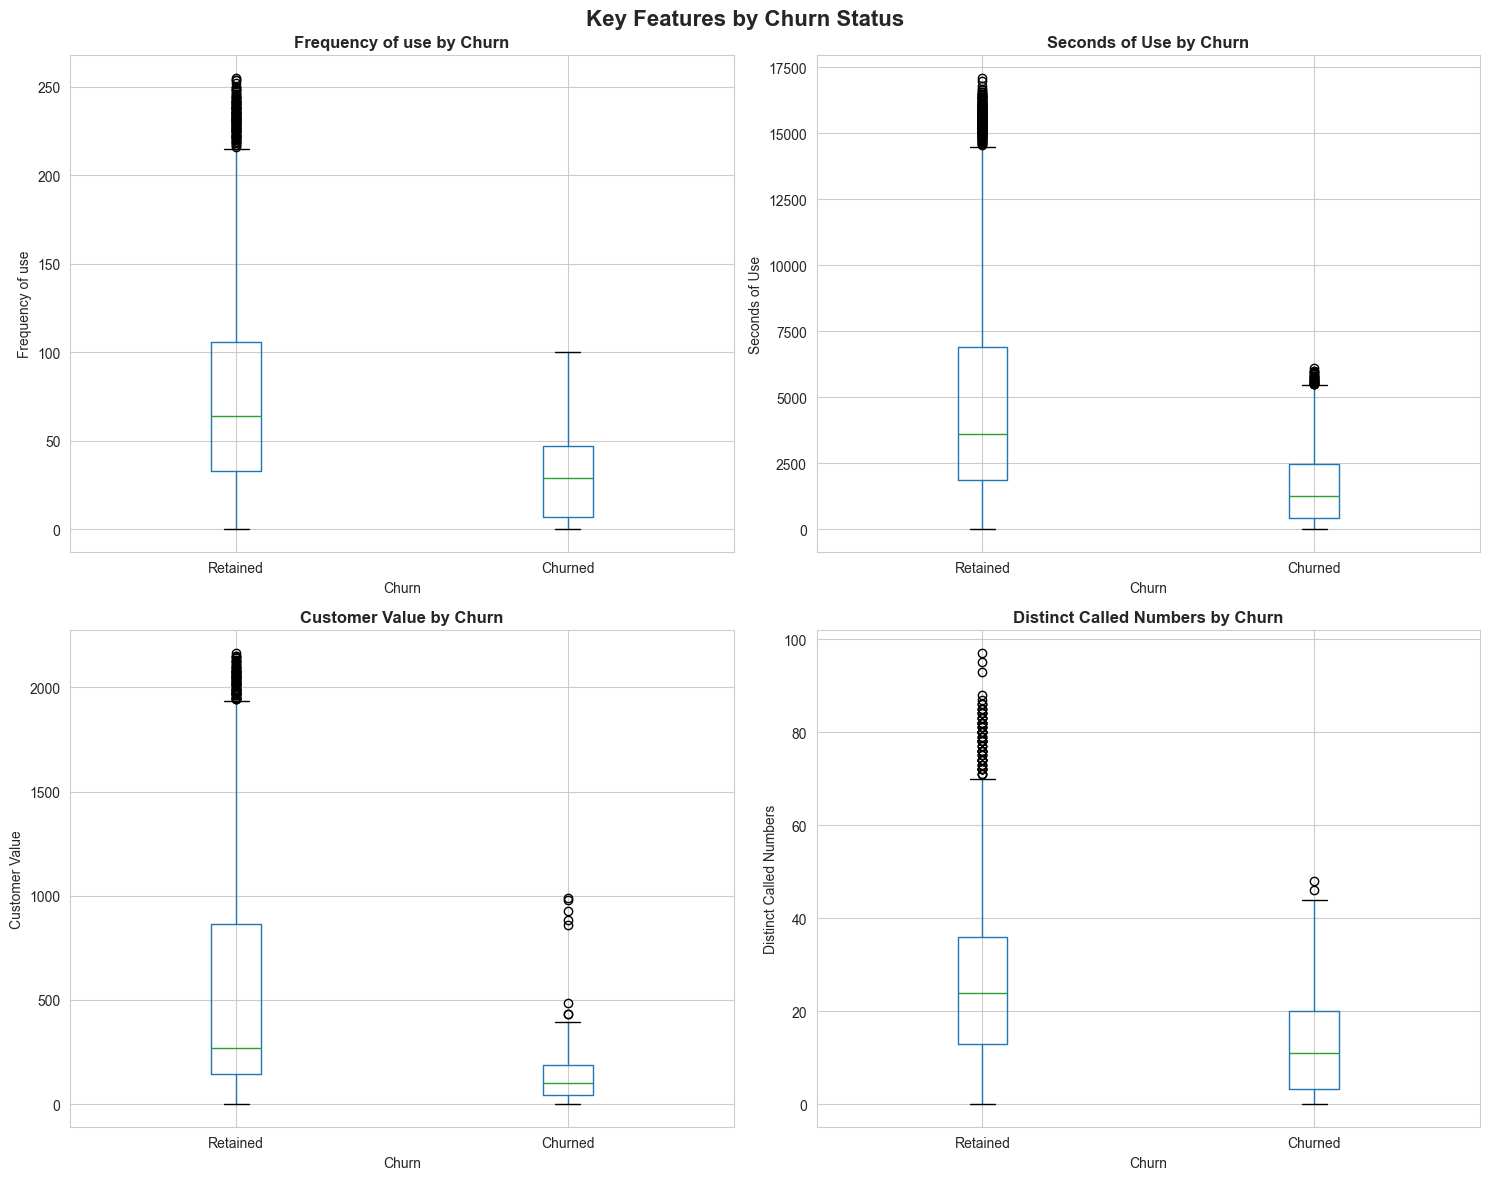

In [16]:
# Box plots - Key features by Churn
features_to_plot = ['Frequency of use', 'Seconds of Use', 'Customer Value', 'Distinct Called Numbers']

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    df_clean.boxplot(column=feature, by='Churn', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Churn', fontweight='bold')
    axes[idx].set_xlabel('Churn')
    axes[idx].set_ylabel(feature)
    axes[idx].get_figure().suptitle('')
    axes[idx].set_xticklabels(['Retained', 'Churned'])

plt.suptitle('Key Features by Churn Status', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

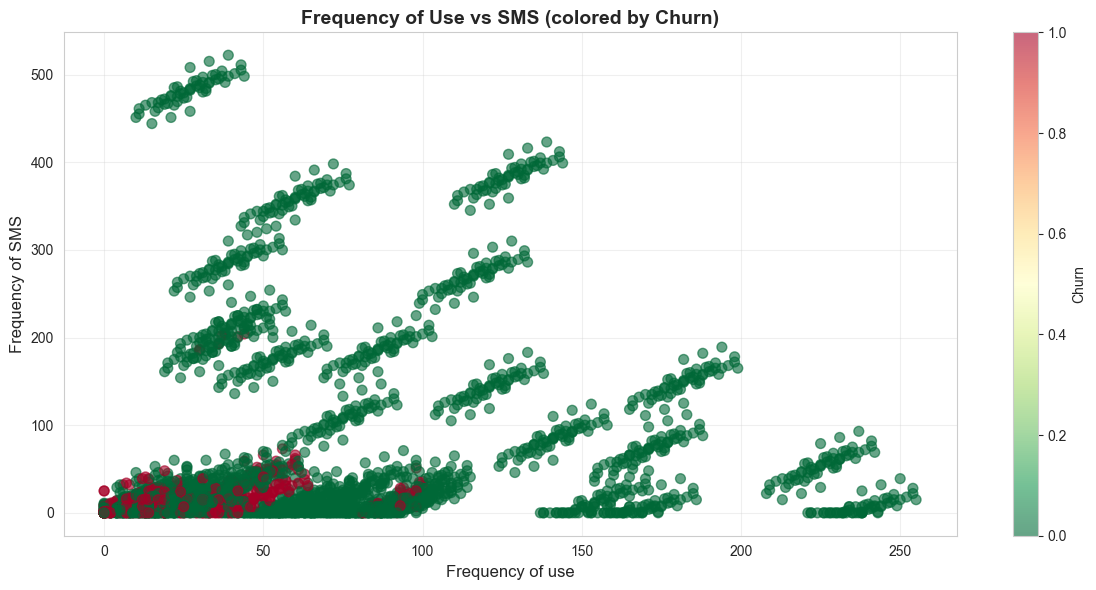

In [17]:
# Scatter plot - Frequency of use vs Frequency of SMS
plt.figure(figsize=(12, 6))
scatter = plt.scatter(df_clean['Frequency of use'], df_clean['Frequency of SMS'],
                      c=df_clean['Churn'], cmap='RdYlGn_r', alpha=0.6, s=50)
plt.colorbar(scatter, label='Churn')
plt.xlabel('Frequency of use', fontsize=12)
plt.ylabel('Frequency of SMS', fontsize=12)
plt.title('Frequency of Use vs SMS (colored by Churn)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Data Normalization

In [18]:
# Separate features and target
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (2850, 13)
Target shape: (2850,)


StandardScaler (Z-score normalization)

In [19]:
scaler_standard = StandardScaler()
X_standard = scaler_standard.fit_transform(X)
X_standard_df = pd.DataFrame(X_standard, columns=X.columns)

print("StandardScaler (Mean ≈ 0, Std ≈ 1):")
print(X_standard_df.describe().loc[['mean', 'std']].round(4))

StandardScaler (Mean ≈ 0, Std ≈ 1):
      Call  Failure  Complains  Subscription  Length  Charge  Amount  \
mean         0.0000     0.0000               -0.0000          0.0000   
std          1.0002     1.0002                1.0002          1.0002   

      Seconds of Use  Frequency of use  Frequency of SMS  \
mean         -0.0000            0.0000            0.0000   
std           1.0002            1.0002            1.0002   

      Distinct Called Numbers  Age Group  Tariff Plan  Status     Age  \
mean                   0.0000     0.0000       0.0000 -0.0000  0.0000   
std                    1.0002     1.0002       1.0002  1.0002  1.0002   

      Customer Value  
mean          0.0000  
std           1.0002  


MinMaxScaler (Range [0, 1])

In [20]:
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)
X_minmax_df = pd.DataFrame(X_minmax, columns=X.columns)

print("MinMaxScaler (Min = 0, Max = 1):")
print(X_minmax_df.describe().loc[['min', 'max']].round(4))

MinMaxScaler (Min = 0, Max = 1):
     Call  Failure  Complains  Subscription  Length  Charge  Amount  \
min            0.0        0.0                   0.0             0.0   
max            1.0        1.0                   1.0             1.0   

     Seconds of Use  Frequency of use  Frequency of SMS  \
min             0.0               0.0               0.0   
max             1.0               1.0               1.0   

     Distinct Called Numbers  Age Group  Tariff Plan  Status  Age  \
min                      0.0        0.0          0.0     0.0  0.0   
max                      1.0        1.0          1.0     1.0  1.0   

     Customer Value  
min             0.0  
max             1.0  


RobustScaler

In [21]:
scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)
X_robust_df = pd.DataFrame(X_robust, columns=X.columns)

print("RobustScaler (Uses median and IQR):")
print(X_robust_df.describe().loc[['50%']].round(4))

RobustScaler (Uses median and IQR):
     Call  Failure  Complains  Subscription  Length  Charge  Amount  \
50%            0.0        0.0                   0.0             0.0   

     Seconds of Use  Frequency of use  Frequency of SMS  \
50%             0.0               0.0               0.0   

     Distinct Called Numbers  Age Group  Tariff Plan  Status  Age  \
50%                      0.0        0.0          0.0     0.0  0.0   

     Customer Value  
50%             0.0  


Comparison of Normalization Methods

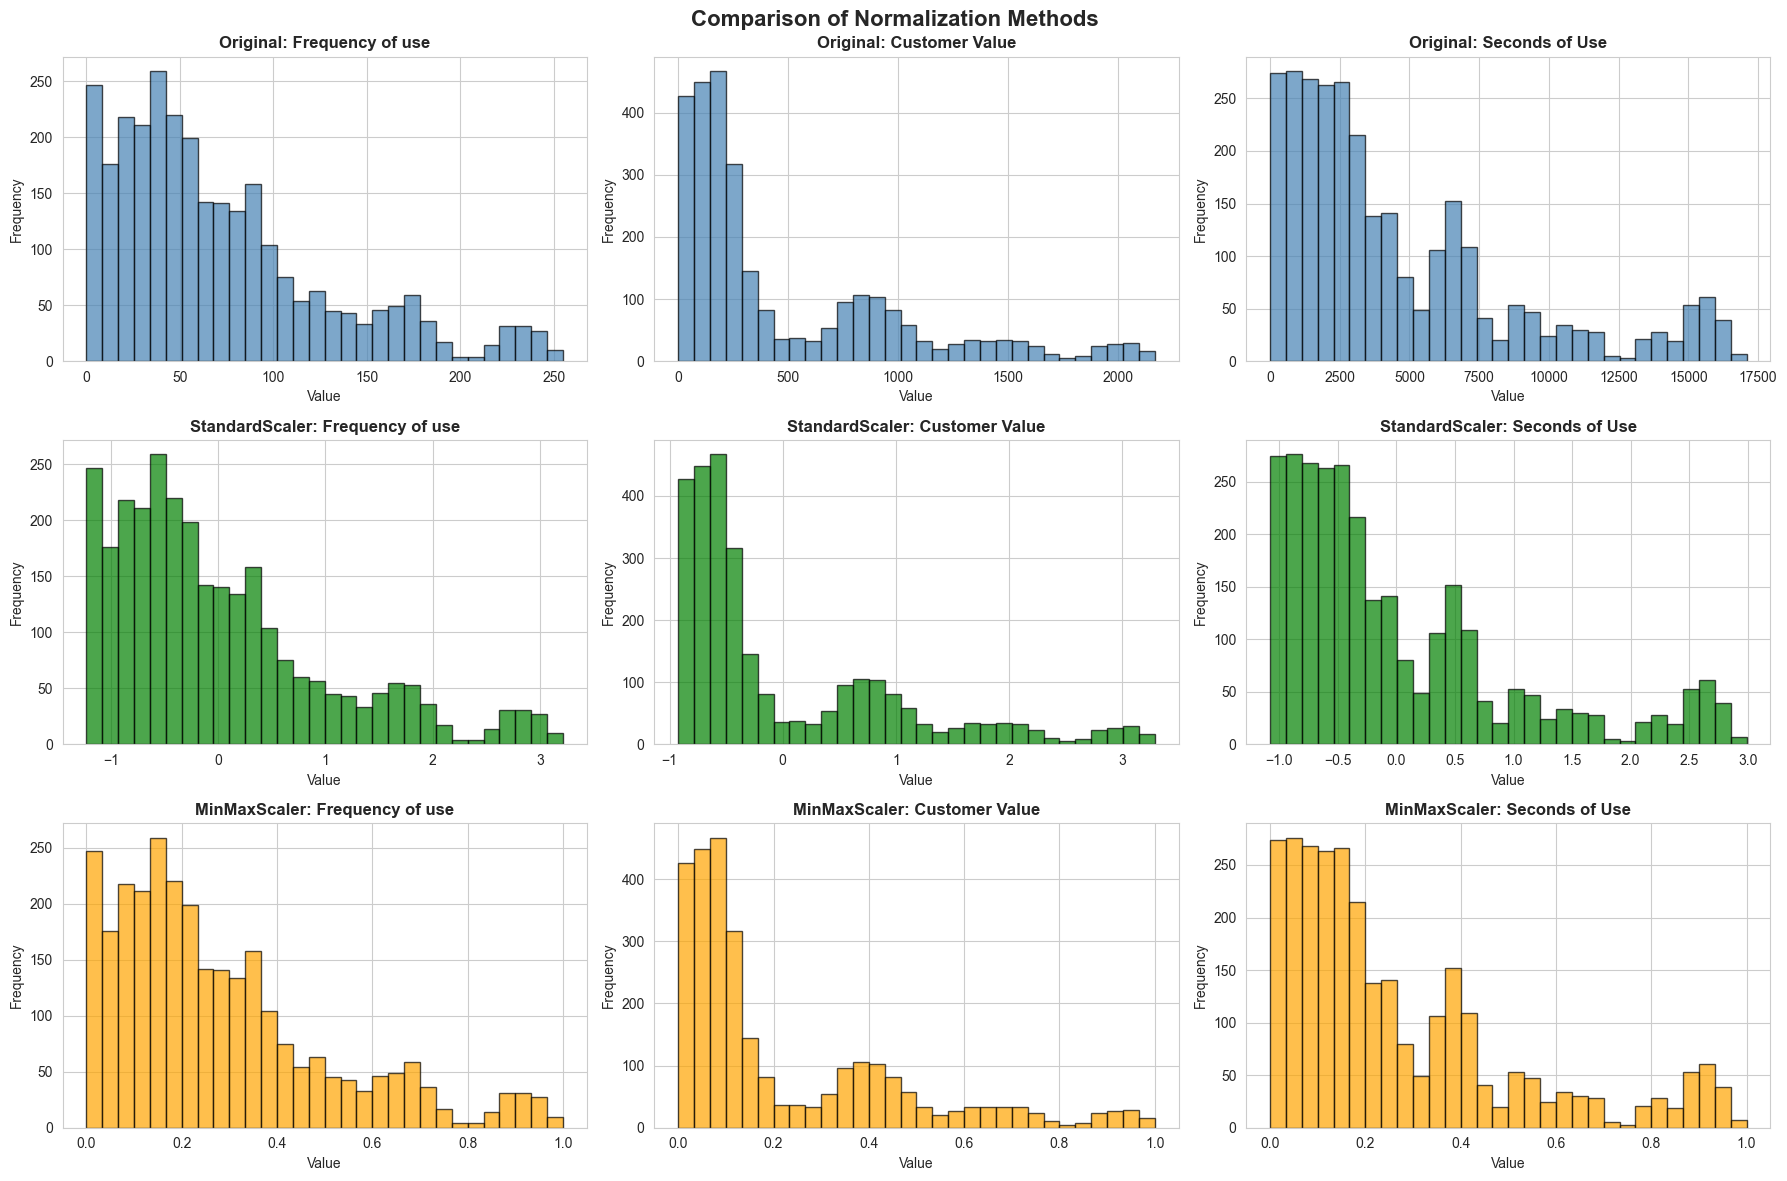

In [22]:
# Compare normalization on selected features
features_to_compare = ['Frequency of use', 'Customer Value', 'Seconds of Use']

fig, axes = plt.subplots(3, len(features_to_compare), figsize=(18, 12))

for idx, feature in enumerate(features_to_compare):
    # Original
    axes[0, idx].hist(df_clean[feature], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'Original: {feature}', fontweight='bold')
    axes[0, idx].set_xlabel('Value')
    axes[0, idx].set_ylabel('Frequency')
    
    # StandardScaler
    axes[1, idx].hist(X_standard_df[feature], bins=30, color='green', edgecolor='black', alpha=0.7)
    axes[1, idx].set_title(f'StandardScaler: {feature}', fontweight='bold')
    axes[1, idx].set_xlabel('Value')
    axes[1, idx].set_ylabel('Frequency')
    
    # MinMaxScaler
    axes[2, idx].hist(X_minmax_df[feature], bins=30, color='orange', edgecolor='black', alpha=0.7)
    axes[2, idx].set_title(f'MinMaxScaler: {feature}', fontweight='bold')
    axes[2, idx].set_xlabel('Value')
    axes[2, idx].set_ylabel('Frequency')

plt.suptitle('Comparison of Normalization Methods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
Detailed Correlation Analysis


Correlation with Churn (Target Variable):
Churn                      1.000000
Complains                  0.546055
Status                     0.492867
Call  Failure              0.003310
Age Group                 -0.005891
Age                       -0.011491
Subscription  Length      -0.037984
Tariff Plan               -0.106000
Charge  Amount            -0.201662
Frequency of SMS          -0.218894
Distinct Called Numbers   -0.270343
Customer Value            -0.287078
Seconds of Use            -0.295999
Frequency of use          -0.298608
Name: Churn, dtype: float64
STRONG CORRELATIONS WITH CHURN

Features with |correlation| > 0.2:
Complains                  0.546055
Status                     0.492867
Charge  Amount            -0.201662
Frequency of SMS          -0.218894
Distinct Called Numbers   -0.270343
Customer Value            -0.287078
Seconds of Use            -0.295999
Frequency of use          -0.298608
Name: Churn, dtype: float64
MULTICOLLINEARITY DETECTION

Highly correl

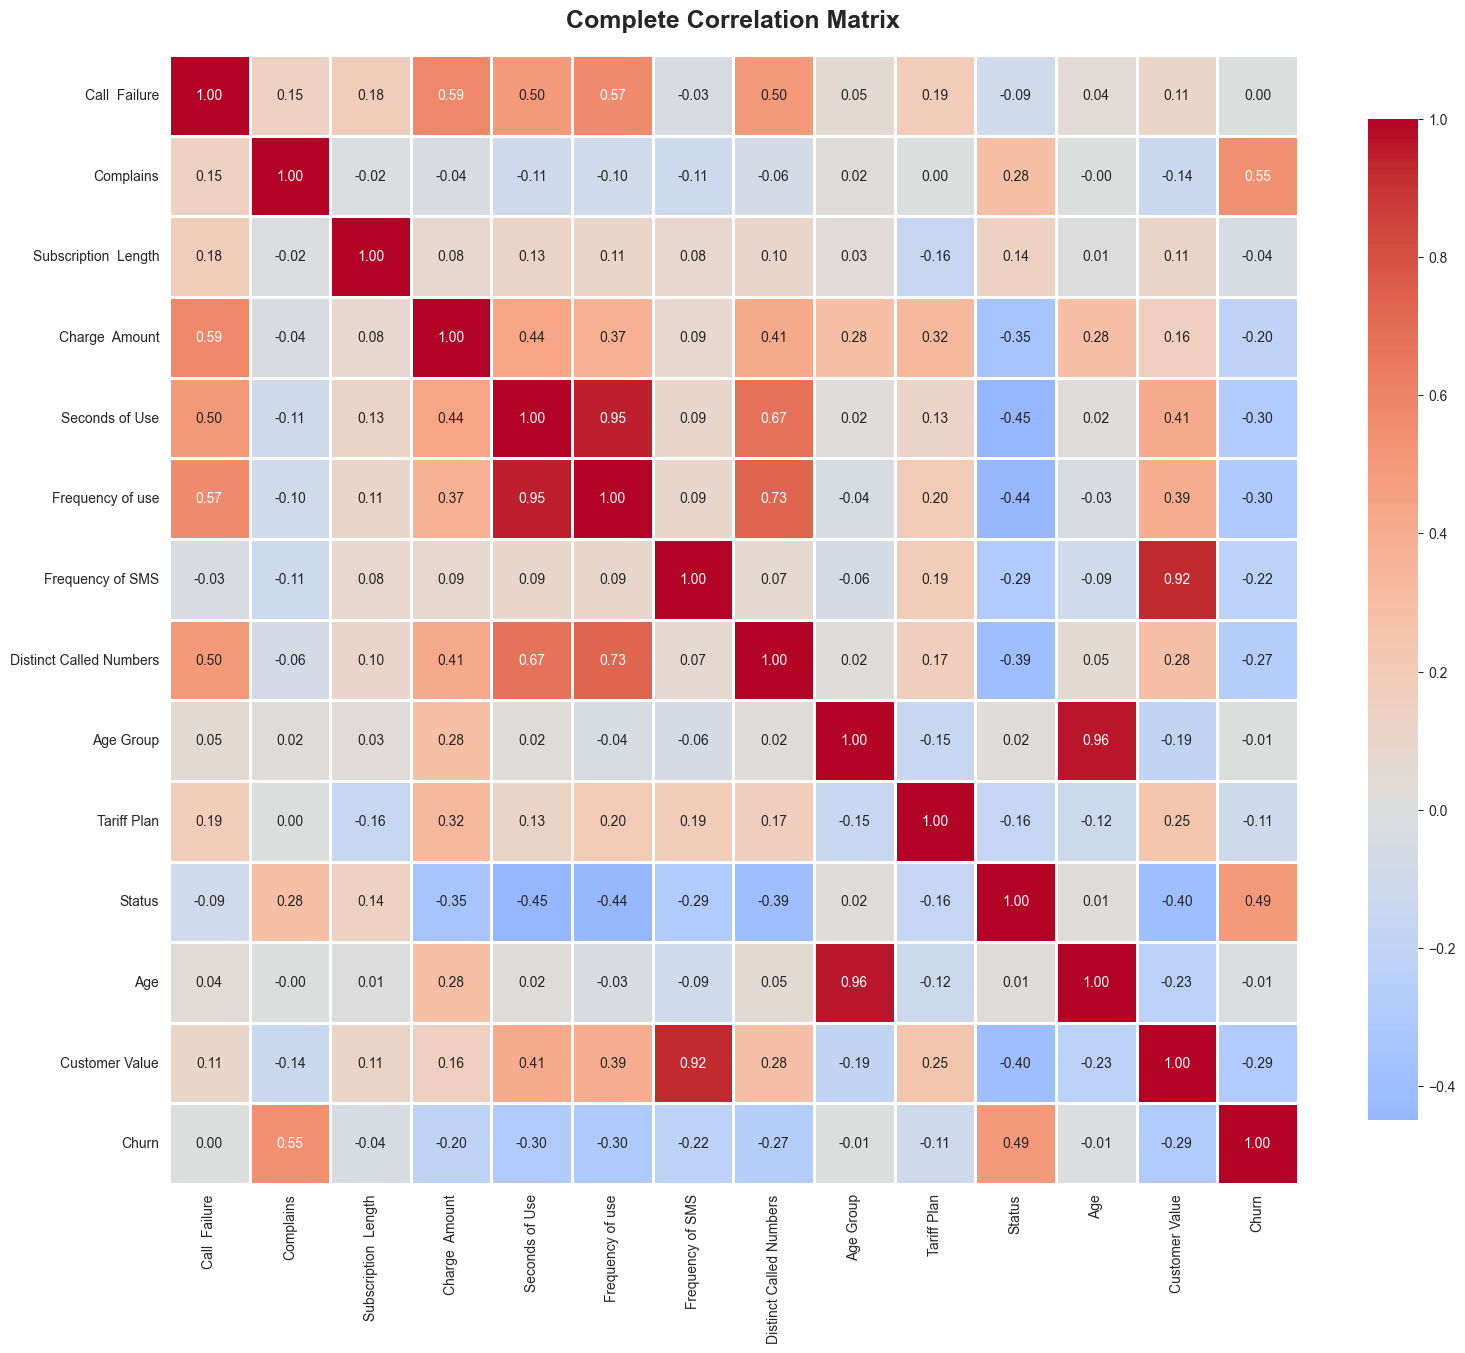

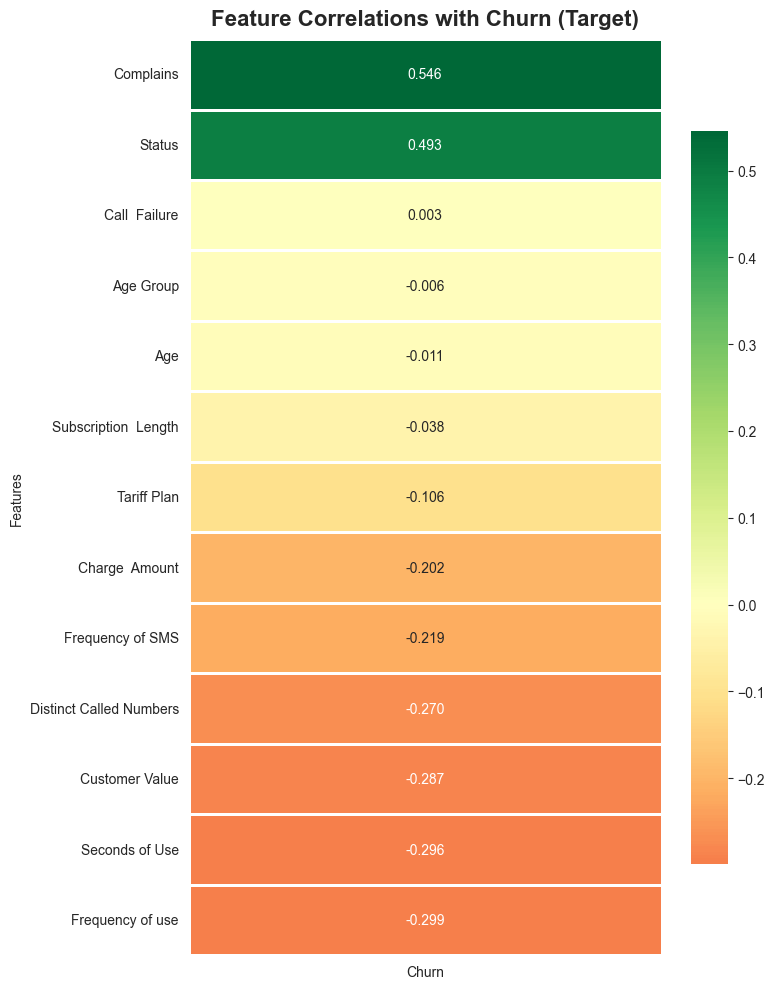

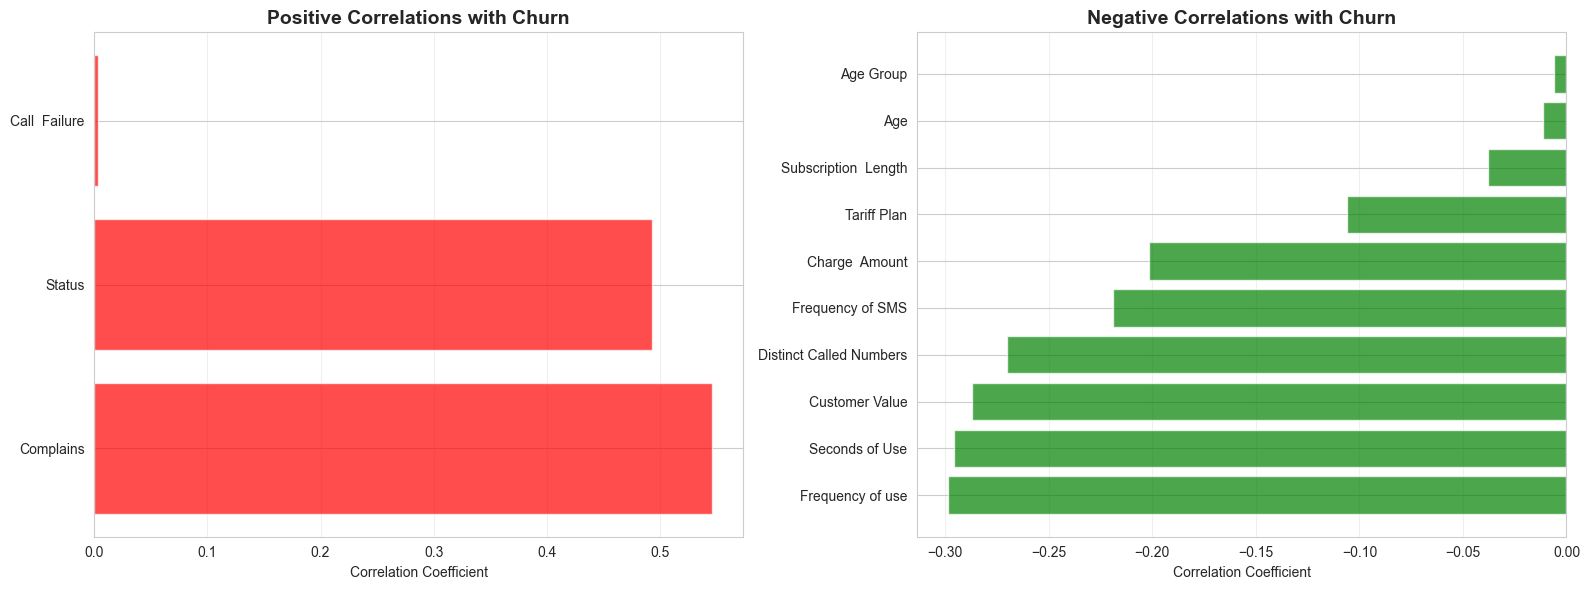

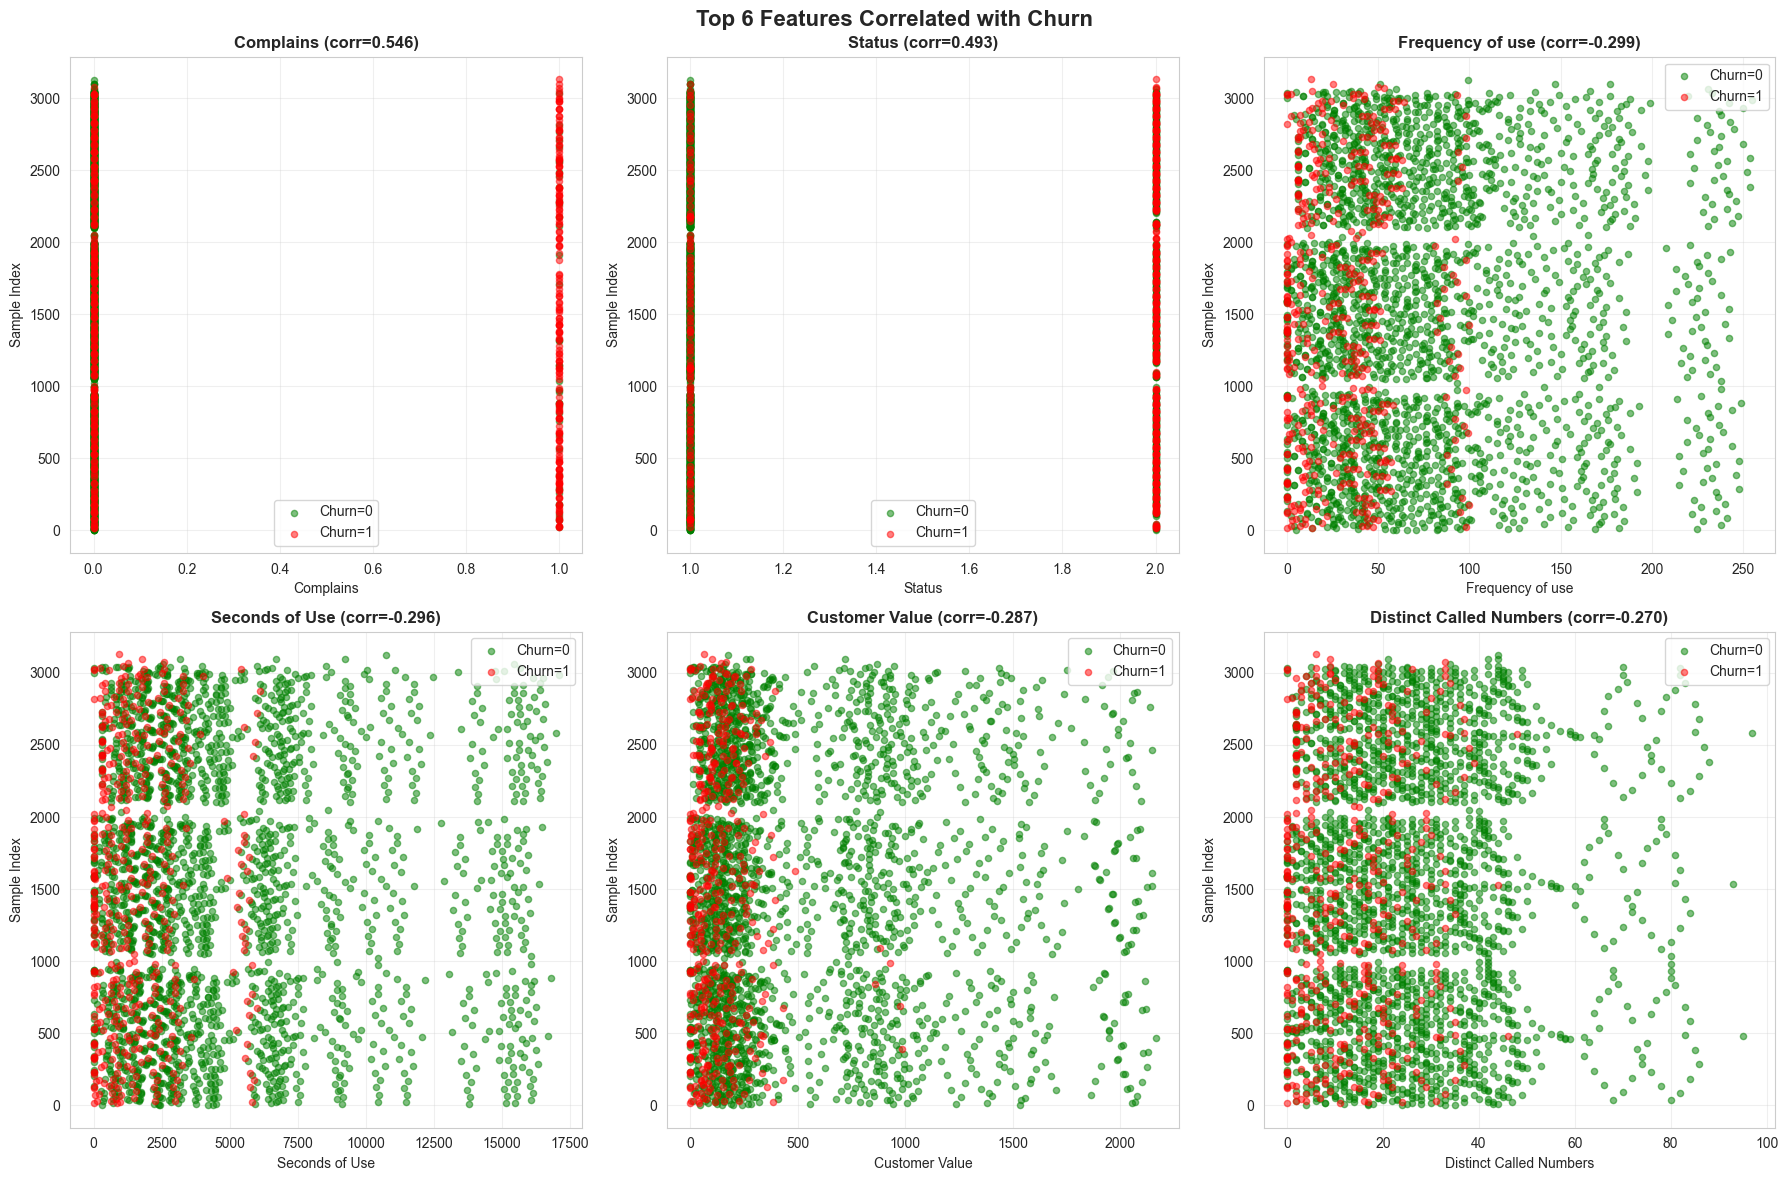

Creating pairplot for top 4 correlated features...


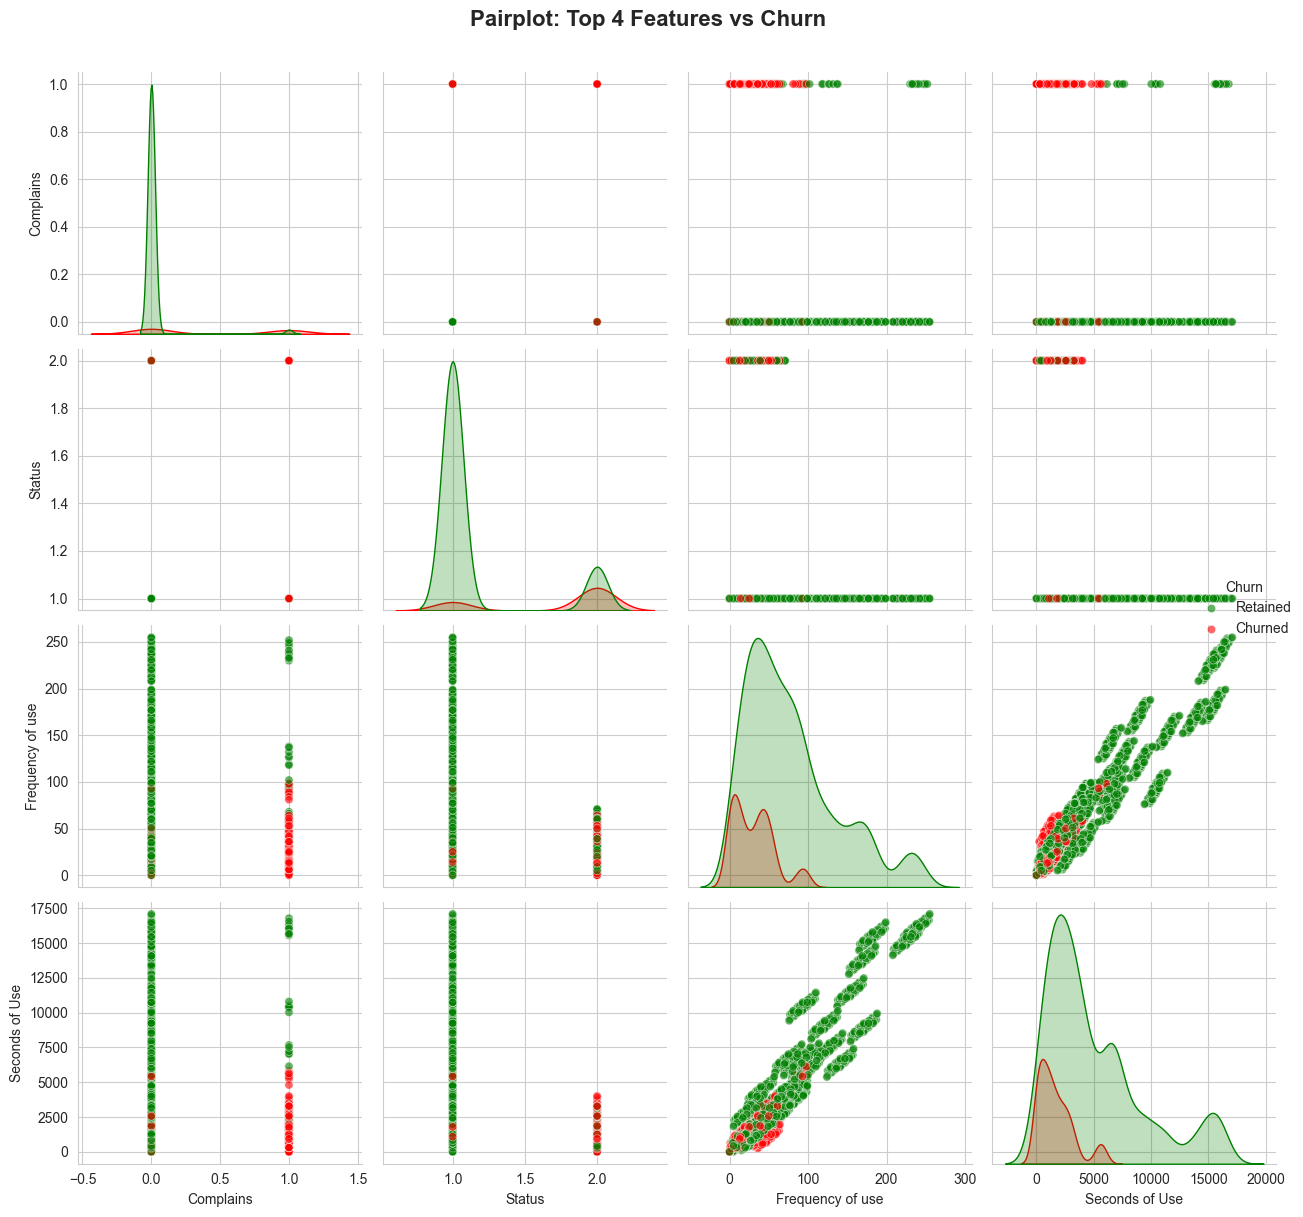

FEATURE STATISTICS BY CHURN STATUS

Complains:
--------------------------------------------------------------------------------
          Churned     Retained   Difference
count  446.000000  2404.000000 -1958.000000
mean     0.426009     0.016639     0.409370
std      0.495050     0.127941     0.367109
min      0.000000     0.000000     0.000000
25%      0.000000     0.000000     0.000000
50%      0.000000     0.000000     0.000000
75%      1.000000     0.000000     1.000000
max      1.000000     1.000000     0.000000

Correlation with Churn: 0.546

Status:
--------------------------------------------------------------------------------
         Churned     Retained   Difference
count  446.00000  2404.000000 -1958.000000
mean     1.72870     1.149334     0.579365
std      0.44513     0.356492     0.088638
min      1.00000     1.000000     0.000000
25%      1.00000     1.000000     0.000000
50%      2.00000     1.000000     1.000000
75%      2.00000     1.000000     1.000000
max      2.

In [24]:
correlation_matrix = df_clean.corr()

# Display correlation with target variable (Churn)
print("\nCorrelation with Churn (Target Variable):")
churn_corr = correlation_matrix['Churn'].sort_values(ascending=False)
print(churn_corr)

print("STRONG CORRELATIONS WITH CHURN")

threshold = 0.2
strong_corr = churn_corr[abs(churn_corr) > threshold]
strong_corr = strong_corr.drop('Churn')  # Remove self-correlation

print(f"\nFeatures with |correlation| > {threshold}:")
print(strong_corr)

print("MULTICOLLINEARITY DETECTION")

# Get correlation between features (excluding target)
features_corr = df_clean.drop('Churn', axis=1).corr()

# Find pairs with high correlation
high_corr_pairs = []
for i in range(len(features_corr.columns)):
    for j in range(i+1, len(features_corr.columns)):
        if abs(features_corr.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature 1': features_corr.columns[i],
                'Feature 2': features_corr.columns[j],
                'Correlation': features_corr.iloc[i, j]
            })

if high_corr_pairs:
    print("\nHighly correlated feature pairs (|r| > 0.7):")
    for pair in high_corr_pairs:
        print(f"  {pair['Feature 1']} <-> {pair['Feature 2']}: {pair['Correlation']:.3f}")
else:
    print("\nNo highly correlated feature pairs found (|r| > 0.7)")

# %% [code]
# Correlation heatmap - Full matrix
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Complete Correlation Matrix', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# %% [code]
# Correlation heatmap - Only with Churn
churn_corr_df = pd.DataFrame(churn_corr.drop('Churn')).sort_values('Churn', ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(churn_corr_df, annot=True, fmt='.3f', cmap='RdYlGn', 
            center=0, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlations with Churn (Target)', fontsize=16, fontweight='bold', pad=10)
plt.xlabel('')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# %% [code]
# Bar plot of correlations with Churn
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive correlations
positive_corr = churn_corr[churn_corr > 0].drop('Churn').sort_values(ascending=False)
axes[0].barh(positive_corr.index, positive_corr.values, color='red', alpha=0.7)
axes[0].set_xlabel('Correlation Coefficient')
axes[0].set_title('Positive Correlations with Churn', fontweight='bold', fontsize=14)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].grid(axis='x', alpha=0.3)

# Negative correlations
negative_corr = churn_corr[churn_corr < 0].sort_values(ascending=True)
axes[1].barh(negative_corr.index, negative_corr.values, color='green', alpha=0.7)
axes[1].set_xlabel('Correlation Coefficient')
axes[1].set_title('Negative Correlations with Churn', fontweight='bold', fontsize=14)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# %% [code]
# Scatter plots for top correlated features
top_features = churn_corr.drop('Churn').abs().sort_values(ascending=False).head(6).index

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    for churn_val in [0, 1]:
        data = df_clean[df_clean['Churn'] == churn_val]
        axes[idx].scatter(data[feature], data.index, 
                         alpha=0.5, s=20, 
                         label=f'Churn={churn_val}',
                         color='green' if churn_val == 0 else 'red')
    
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Sample Index')
    axes[idx].set_title(f'{feature} (corr={churn_corr[feature]:.3f})', fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Top 6 Features Correlated with Churn', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# %% [code]
# Pairplot for top 4 correlated features (with Churn)
top_4_features = churn_corr.drop('Churn').abs().sort_values(ascending=False).head(4).index.tolist()
features_for_pairplot = top_4_features + ['Churn']

print("Creating pairplot for top 4 correlated features...")
pairplot_data = df_clean[features_for_pairplot].copy()
pairplot_data['Churn'] = pairplot_data['Churn'].map({0: 'Retained', 1: 'Churned'})

sns.pairplot(pairplot_data, hue='Churn', palette={'Retained': 'green', 'Churned': 'red'},
             diag_kind='kde', plot_kws={'alpha': 0.6}, height=3)
plt.suptitle('Pairplot: Top 4 Features vs Churn', y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("FEATURE STATISTICS BY CHURN STATUS")

top_5_features = churn_corr.drop('Churn').abs().sort_values(ascending=False).head(5).index

for feature in top_5_features:
    print(f"\n{feature}:")
    print("-"*80)
    
    churned_stats = df_clean[df_clean['Churn']==1][feature].describe()
    retained_stats = df_clean[df_clean['Churn']==0][feature].describe()
    
    comparison_df = pd.DataFrame({
        'Churned': churned_stats,
        'Retained': retained_stats,
        'Difference': churned_stats - retained_stats
    })
    
    print(comparison_df)
    print(f"\nCorrelation with Churn: {churn_corr[feature]:.3f}")